# 1-Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('customer_churn_data.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST0000,Male,0,No,Yes,23,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer,49.85,1146.55,No
1,CUST0001,Female,0,Yes,No,43,No,No phone service,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,100.70,4330.10,Yes
2,CUST0002,Male,1,No,No,51,Yes,No,DSL,No,...,Yes,Yes,No,No,One year,No,Electronic check,97.33,4963.83,Yes
3,CUST0003,Male,1,No,No,72,Yes,Yes,DSL,Yes,...,Yes,No,No,No,Month-to-month,No,Credit card,101.38,7299.36,No
4,CUST0004,Male,1,No,No,25,Yes,Yes,DSL,No,...,No,Yes,No,Yes,Month-to-month,No,Electronic check,52.22,1305.50,Yes


In [3]:
data.dtypes.value_counts()

object     17
int64       2
float64     2
Name: count, dtype: int64

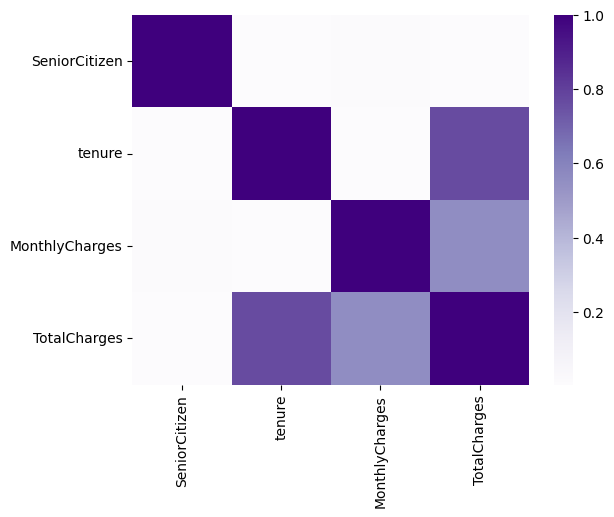

In [4]:
sns.heatmap(data.corr(numeric_only=True), cmap="Purples")
plt.show()

<Axes: >

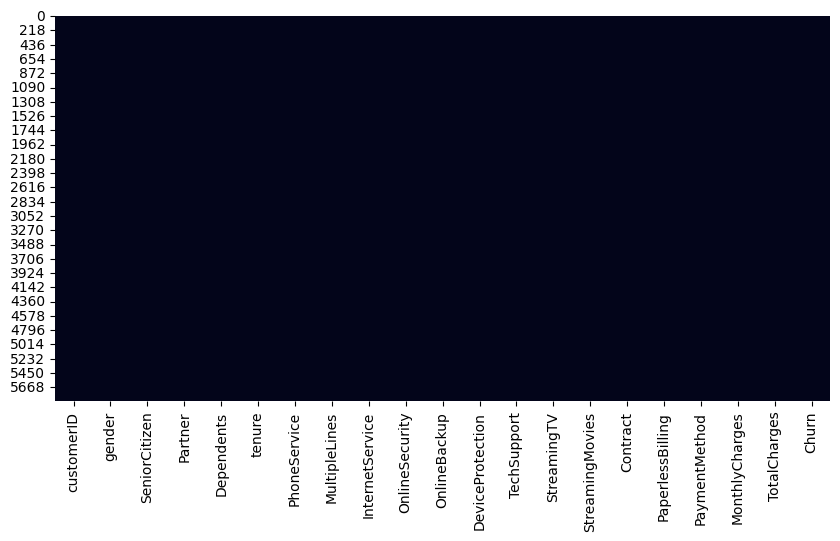

In [5]:
plt.figure(figsize=(10,5))
sns.heatmap(data.isna(), cbar= False)

In [6]:
(data.isna().sum()/data.shape[0]).sort_values(ascending= True)

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

In [7]:
pos_churns=data[data['Churn'] == 'Yes']
neg_churns = data[data['Churn'] == 'No']

# 2-Data Preprocessing

In [8]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(data, 
    test_size=0.2, 
    random_state=42, 
    stratify= data['Churn'])

In [9]:
test_set['Churn'].value_counts()

Churn
No     596
Yes    580
Name: count, dtype: int64

In [10]:
categ_columns = data.select_dtypes('object').columns.tolist()
categ_columns

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [11]:
for col in categ_columns:
    print(f'{50*'*'} Column: {col} {50*'*'}\n {data[col].value_counts()}\n')

************************************************** Column: customerID **************************************************
 customerID
CUST5879    1
CUST0000    1
CUST0001    1
CUST0002    1
CUST0003    1
           ..
CUST0012    1
CUST0011    1
CUST0010    1
CUST0009    1
CUST0008    1
Name: count, Length: 5880, dtype: int64

************************************************** Column: gender **************************************************
 gender
Male      2950
Female    2930
Name: count, dtype: int64

************************************************** Column: Partner **************************************************
 Partner
Yes    2995
No     2885
Name: count, dtype: int64

************************************************** Column: Dependents **************************************************
 Dependents
No     3004
Yes    2876
Name: count, dtype: int64

************************************************** Column: PhoneService **************************************************
 Phon

In [12]:
def encodage(df):
    code = {
        'No' : 0,
        'Yes' : 1,
        'No internet service' : 2,
        'Male' : 0,
        'Female' : 1,
        'DSL' : 5,
        'Fiber optic' : 10,
        'Credit card': 11,
        'Electronic check' : 12,
        'Mailed check' : 13,
        'Bank transfer' : 14,
        'Month-to-month' : 21,
        'One year' : 22,
        'Two year' : 23
        }
    
    for col in df.select_dtypes('object').columns:

        if col != 'MultipleLines':
            df.loc[:,col] = df[col].map(code)
               
    return df

def imputation(df):
    return df.dropna(axis=0)

def extracting(df):
    benefits= ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    df['Total_Benefits'] = (df[benefits] == 1).sum(axis=1)
    df = df.drop(benefits, axis =1)

    family_cols = ['SeniorCitizen', 'Partner', 'Dependents']
    df['Family_Score'] = df[family_cols].sum(axis=1)
    df = df.drop(family_cols, axis=1)
    
    phone_map = {'No phone service': 0, 'No': 1, 'Yes': 2}
    df['MultipleLines'] = df['MultipleLines'].replace(phone_map)
    df = df.drop('PhoneService', axis=1)
    
    return df
        

In [13]:
def preprocessor(df):
    
    if 'customerID' in df.columns:
        df = df.drop('customerID', axis=1)
        
    df = encodage(df)
    df = imputation(df)
    df = df.drop('TotalCharges', axis=1)
    df = extracting(df)

    X= df.drop('Churn', axis=1).astype('int')
    y= df['Churn'].astype('int')
    
    return X,y

In [14]:
X_train ,y_train = preprocessor(train_set)
X_test, y_test = preprocessor(test_set)

C:\Users\MELIODAS\AppData\Local\Temp\ipykernel_10596\3206852021.py:39: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['MultipleLines'] = df['MultipleLines'].replace(phone_map)
C:\Users\MELIODAS\AppData\Local\Temp\ipykernel_10596\3206852021.py:39: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['MultipleLines'] = df['MultipleLines'].replace(phone_map)


In [15]:
X_train

,gender,tenure,MultipleLines,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Total_Benefits,Family_Score
4701,0,46,2,0,22,1,14,83,0,2
1503,0,43,0,5,23,1,12,79,4,3
5063,1,41,2,0,23,1,12,104,0,0
4780,0,44,0,10,23,0,12,55,3,1
2096,1,30,0,0,22,1,12,55,0,2
...,...,...,...,...,...,...,...,...,...,...
1728,1,8,0,10,23,0,11,28,1,2
3803,1,11,1,5,23,1,13,25,3,0
3410,1,66,1,0,21,0,14,45,0,1
1709,1,50,2,5,22,0,14,81,5,1


# 3-Modeling

In [16]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

preprocessor = make_pipeline(PolynomialFeatures(2, include_bias= False))

RandomForest = make_pipeline(preprocessor, RandomForestClassifier(random_state=0))
AdaBoost = make_pipeline(preprocessor, AdaBoostClassifier(random_state=0))
SVM = make_pipeline(preprocessor, StandardScaler(), SVC(random_state=0))
KNN = make_pipeline(preprocessor, StandardScaler(), KNeighborsClassifier())

model_list= {'RandomForest': RandomForest,
             'AdaBoost': AdaBoost,
             'SVM' :SVM ,
             'KNN': KNN
             }


# 4-Validation

In [17]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

def validation(model, X_train, y_train):
    """Diagnoses model learning behavior using cross-validation."""
    print("Running Cross-Validation Learning Curve...")
    N, train_score, val_score = learning_curve(
        model, X_train, y_train, 
        cv=4, scoring='f1', 
        train_sizes=np.linspace(0.1, 1, 10)
    )
    
    plt.figure(figsize=(12, 8))
    plt.plot(N, train_score.mean(axis=1), label='Train Score', color='blue', marker='o')
    plt.plot(N, val_score.mean(axis=1), label='Validation Score', color='orange', marker='s')
    plt.title("Learning Curve (F1 Score)")
    plt.xlabel("Training Set Size")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid(True)
    plt.show()

RandomForest
Running Cross-Validation Learning Curve...


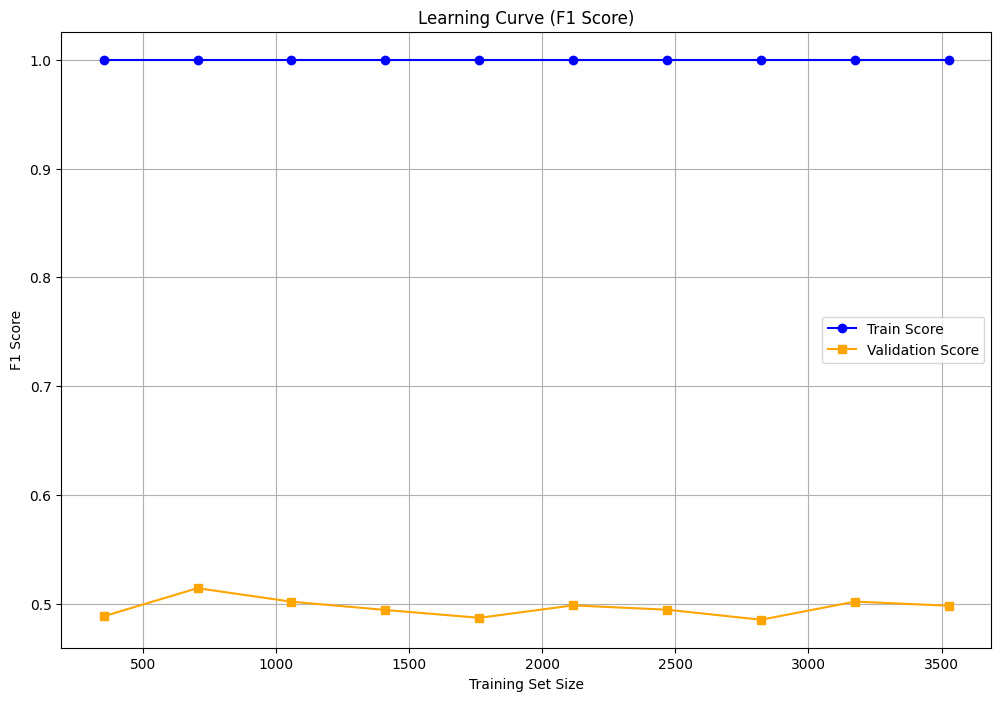

AdaBoost
Running Cross-Validation Learning Curve...


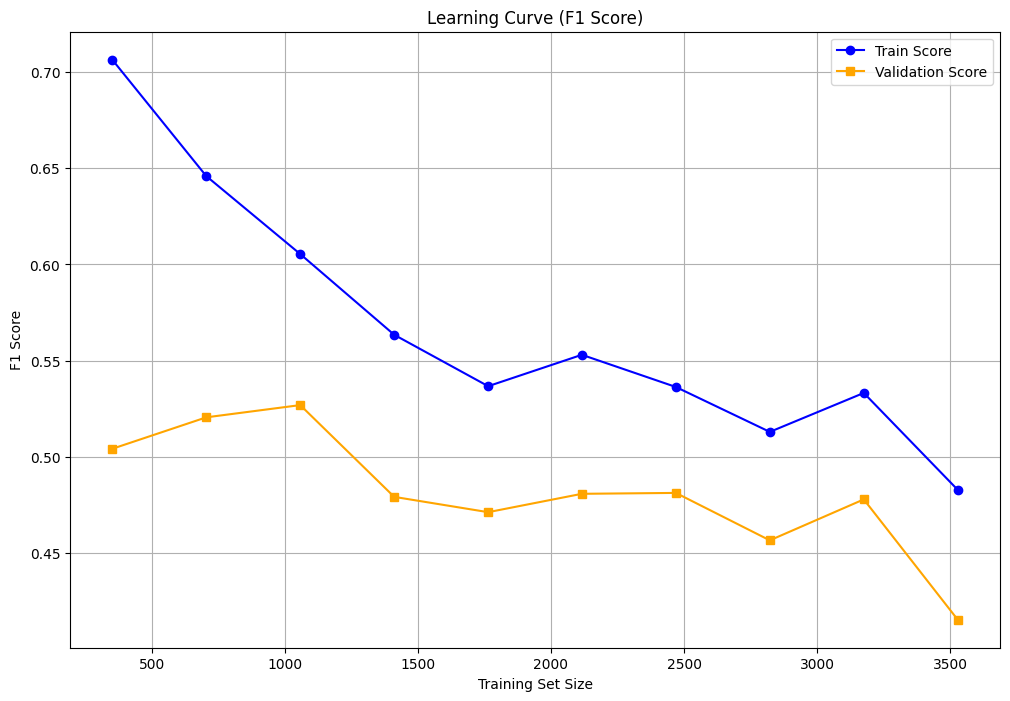

SVM
Running Cross-Validation Learning Curve...


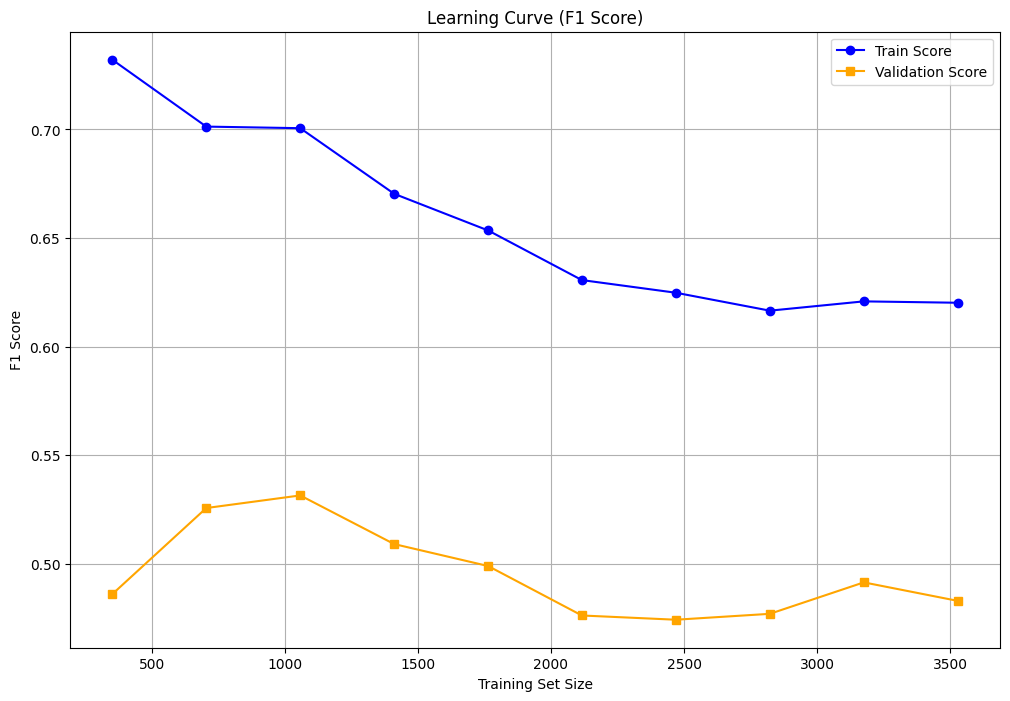

KNN
Running Cross-Validation Learning Curve...


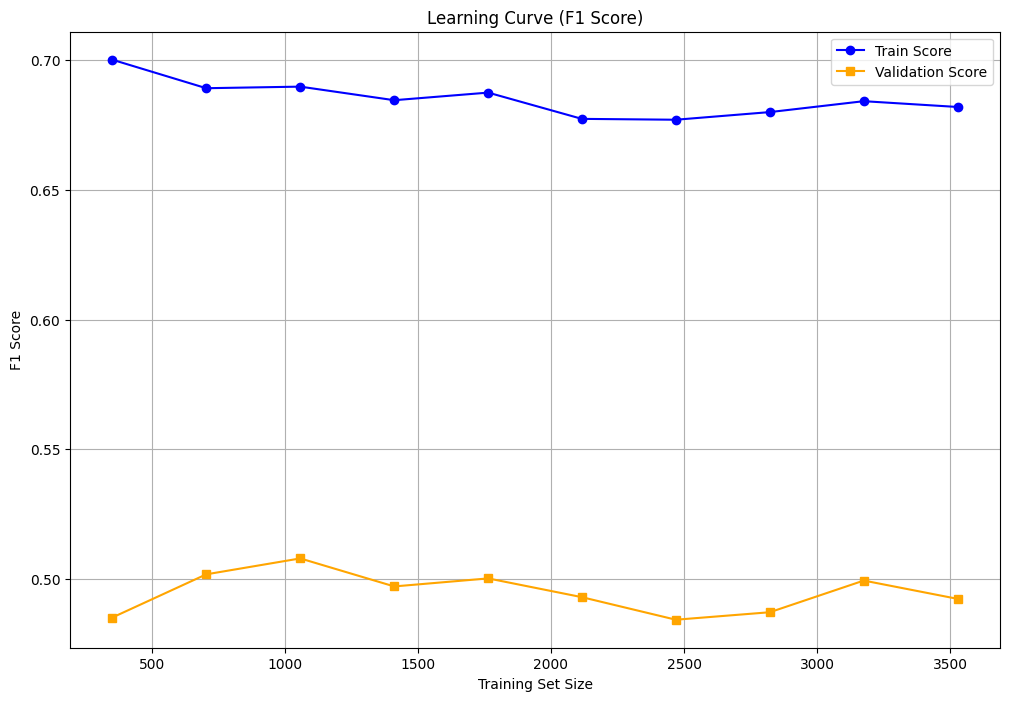

In [18]:
for name, model in model_list.items():
    print(name)
    validation(model,  X_train, y_train)

# 5-Optimization

In [19]:
from sklearn.pipeline import Pipeline

SVM = Pipeline(steps=[
    ('PolyFeatures', PolynomialFeatures(2, include_bias= False)),
    ('standardscaler', StandardScaler()),
    ('svc', SVC(random_state=0, class_weight='balanced'))
    ])

SVM.get_params()

{'memory': None,
 'steps': [('PolyFeatures', PolynomialFeatures(include_bias=False)),
  ('standardscaler', StandardScaler()),
  ('svc', SVC(class_weight='balanced', random_state=0))],
 'transform_input': None,
 'verbose': False,
 'PolyFeatures': PolynomialFeatures(include_bias=False),
 'standardscaler': StandardScaler(),
 'svc': SVC(class_weight='balanced', random_state=0),
 'PolyFeatures__degree': 2,
 'PolyFeatures__include_bias': False,
 'PolyFeatures__interaction_only': False,
 'PolyFeatures__order': 'C',
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'svc__C': 1.0,
 'svc__break_ties': False,
 'svc__cache_size': 200,
 'svc__class_weight': 'balanced',
 'svc__coef0': 0.0,
 'svc__decision_function_shape': 'ovr',
 'svc__degree': 3,
 'svc__gamma': 'scale',
 'svc__kernel': 'rbf',
 'svc__max_iter': -1,
 'svc__probability': False,
 'svc__random_state': 0,
 'svc__shrinking': True,
 'svc__tol': 0.001,
 'svc__verbose': False}

In [20]:
from sklearn.model_selection import GridSearchCV

hyper_params = {
    'svc__gamma' : ['scale', 'auto'],
    'svc__C': [0.1, 1, 10, 100, 1000],
    'svc__kernel' : ['linear', 'poly', 'rbf']
}

grid = GridSearchCV(SVM, hyper_params, scoring='f1', cv =4)
grid.fit(X_train, y_train)
print(grid.best_params_)

{'svc__C': 1000, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}


In [21]:
my_model = grid.best_estimator_

Running Cross-Validation Learning Curve...


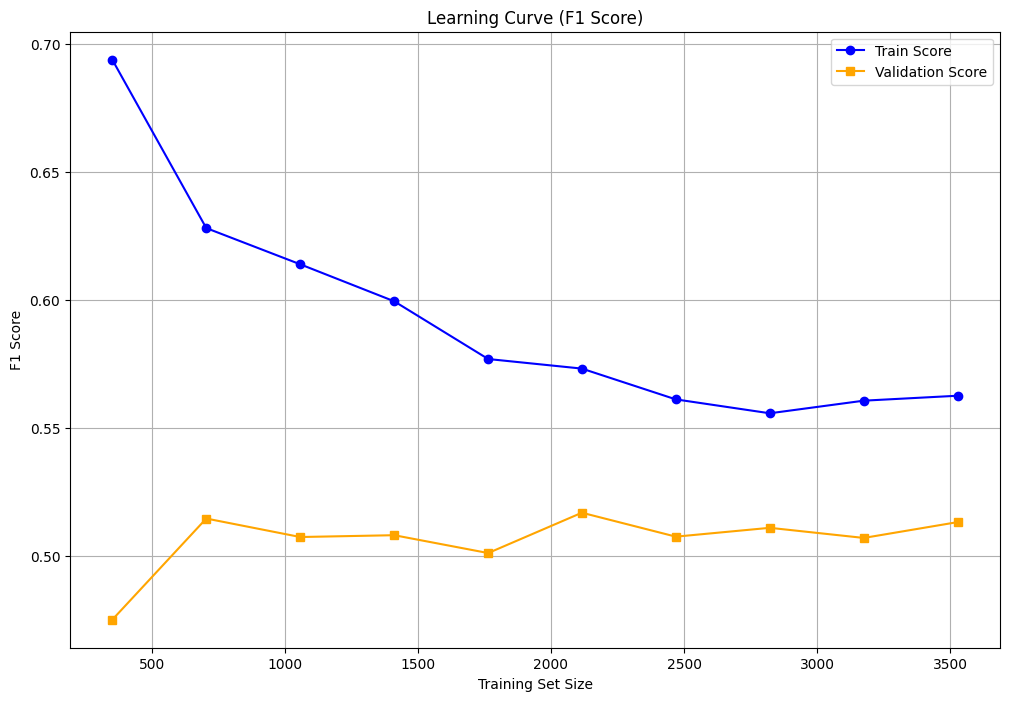

In [23]:
validation(my_model, X_train, y_train)

# 6-Evaluation

In [24]:
from sklearn.metrics import confusion_matrix, classification_report

def evaluation(model, X_test, y_test):
    """The final exam. Evaluates the locked model on unseen data."""
    print("--- FINAL EVALUATION ON UNSEEN TEST DATA ---")
    ypred = model.predict(X_test)
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, ypred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, ypred))

In [25]:
evaluation(my_model, X_test, y_test)

--- FINAL EVALUATION ON UNSEEN TEST DATA ---

Confusion Matrix:
[[236 360]
 [251 329]]

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.40      0.44       596
           1       0.48      0.57      0.52       580

    accuracy                           0.48      1176
   macro avg       0.48      0.48      0.48      1176
weighted avg       0.48      0.48      0.48      1176



# Precision Recall Curve

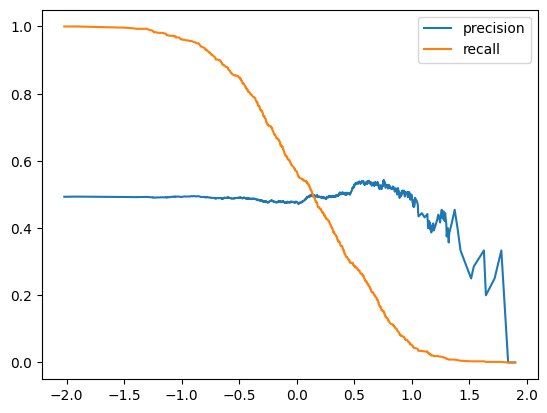

In [27]:
from sklearn.metrics import precision_recall_curve, f1_score, recall_score

precision, recall, threshold = precision_recall_curve(y_test, grid.best_estimator_.decision_function(X_test))

plt.plot(threshold, precision[:-1], label= 'precision')
plt.plot(threshold, recall[:-1], label= 'recall')
plt.legend()

In [28]:
def model_finale(model, X,  threshold=0):
    return model.decision_function(X) > threshold

In [29]:
target_recall = 0.80

def get_custom_predictions(target_recall, threshold_array):
    
    idx = np.abs(recall[:-1] - target_recall).argmin()
    optimal_threshold = threshold_array[idx]

    print("--- BUSINESS DECISION METRICS ---")
    print(f"Target Recall:      {target_recall * 100}%")
    print(f"Expected Precision: {precision[idx] * 100:.2f}%")
    print(f"OPTIMAL THRESHOLD:  {optimal_threshold:.4f}")
    print("---------------------------------")
    
    custom_preds = model_finale(grid.best_estimator_, X_test, threshold=optimal_threshold)
    
    return custom_preds


In [31]:
y_pred = get_custom_predictions(target_recall, threshold)

print(f"\nFinal F1 Score: {f1_score(y_test, y_pred):.2f}")

--- BUSINESS DECISION METRICS ---
Target Recall:      80.0%
Expected Precision: 48.74%
OPTIMAL THRESHOLD:  -0.4050
---------------------------------

Final F1 Score: 0.60


In [33]:
import joblib

joblib.dump(grid.best_estimator_, 'Churn_svm_model.pkl')

print("Model saved successfully!")

Model saved successfully!


# The End ...